## REGRESSION - Fitting a parabola to the given data

Fitted parabola: y = 2.0152 * x^2 + -3.0370 * x + 4.9430
Mean Squared Error: 0.0180


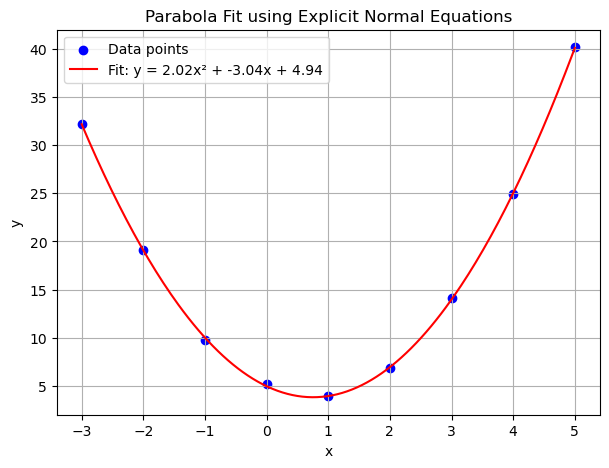

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(2026)

def fit_parabola_normal_equation(x, y):
    """
    Fit a parabola y = a*x^2 + b*x + c to data (x, y) using the
    EXPLICIT normal equations of least-squares regression (derived by
    setting the partial derivatives of the sum-of-squared-errors
    with respect to a, b, and c to zero).

    For y = a*x^2 + b*x + c, minimizing
        S = sum((y_i - a*x_i^2 - b*x_i - c)^2)
    w.r.t. a, b, c gives the three normal equations:

        (1) sum(x^2*y) = a*sum(x^4) + b*sum(x^3) + c*sum(x^2)
        (2) sum(x*y)   = a*sum(x^3) + b*sum(x^2) + c*sum(x)
        (3) sum(y)     = a*sum(x^2) + b*sum(x)   + c*n

    This is a 3x3 linear system in unknowns (a, b, c):

        [ sum(x^4)  sum(x^3)  sum(x^2) ] [a]   [ sum(x^2*y) ]
        [ sum(x^3)  sum(x^2)  sum(x)   ] [b] = [ sum(x*y)   ]
        [ sum(x^2)  sum(x)    n        ] [c]   [ sum(y)     ]

    Parameters
    ----------
    x : array-like, shape (n,)
    y : array-like, shape (n,)

    Returns
    -------
    a : float  -> coefficient of x^2
    b : float  -> coefficient of x
    c : float  -> intercept
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    # Compute the required summations (powers of x up to 4, and cross terms with y)
    sum_x  = np.sum(x)
    sum_x2 = np.sum(x ** 2)
    sum_x3 = np.sum(x ** 3)
    sum_x4 = np.sum(x ** 4)
    sum_y   = np.sum(y)
    sum_xy  = np.sum(x * y)
    sum_x2y = np.sum((x ** 2) * y)

    # Coefficient matrix A (from the normal equations) and RHS vector B
    A = [
        [sum_x4, sum_x3, sum_x2],
        [sum_x3, sum_x2, sum_x],
        [sum_x2, sum_x,  n],
    ]
    B = [sum_x2y, sum_xy, sum_y]

    # Solve the 3x3 system A @ [a, b, c] = B using np.linalg.solve
    a, b, c = np.linalg.solve(np.array(A), np.array(B))

    return a, b, c


# ----- Example / test data (points roughly following y = 2x^2 - 3x + 5) -----
x_data = np.array([-3, -2, -1, 0, 1, 2, 3, 4, 5])
y_data = np.array([32.2, 19.1, 9.8, 5.2, 3.9, 6.8, 14.1, 24.9, 40.2])


# Fit parabola using explicit normal equations
a, b, c = fit_parabola_normal_equation(x_data, y_data)
print(f"Fitted parabola: y = {a:.4f} * x^2 + {b:.4f} * x + {c:.4f}")

# Predictions
y_pred = a * x_data ** 2 + b * x_data + c

# Mean Squared Error (goodness of fit)
mse = np.mean((y_data - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

# ----- Plot -----
x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_smooth = a * x_smooth ** 2 + b * x_smooth + c

plt.figure(figsize=(7, 5))
plt.scatter(x_data, y_data, color="blue", label="Data points")
plt.plot(x_smooth, y_smooth, color="red",
             label=f"Fit: y = {a:.2f}x² + {b:.2f}x + {c:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabola Fit using Explicit Normal Equations")
plt.legend()
plt.grid(True)
plt.show()
    

Fitted parabola: y = 1.0125 * x^2 + -0.5888 * x + 2.5256
Mean Squared Error: 3.0142


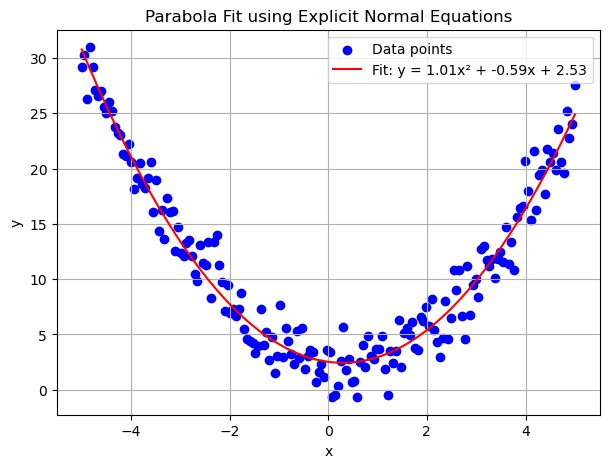

In [2]:
# --- Generate synthetic quadratic data ---
a_true, b_true, c_true = 1.0, -0.6, 2.5
x_data = np.linspace(-5, 5, 180)
noise_sigma = 1.6
y_data = a_true * x_data**2 + b_true * x_data + c_true + rng.normal(0.0, noise_sigma, size=x_data.shape)


# Fit parabola using explicit normal equations
a, b, c = fit_parabola_normal_equation(x_data, y_data)
print(f"Fitted parabola: y = {a:.4f} * x^2 + {b:.4f} * x + {c:.4f}")

# Predictions
y_pred = a * x_data ** 2 + b * x_data + c

# Mean Squared Error (goodness of fit)
mse = np.mean((y_data - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

# ----- Plot -----
x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_smooth = a * x_smooth ** 2 + b * x_smooth + c

plt.figure(figsize=(7, 5))
plt.scatter(x_data, y_data, color="blue", label="Data points")
plt.plot(x_smooth, y_smooth, color="red",
             label=f"Fit: y = {a:.2f}x² + {b:.2f}x + {c:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabola Fit using Explicit Normal Equations")
plt.legend()
plt.grid(True)
plt.show()

## EXERCISES

1. Fit a parabola for the following data and show a plot of the same.

   
   x = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]

   
   y = [84, 56, 34, 18, 8, 4, 6, 14, 28, 48]


2. Let $k$ be the last digit of your Roll Number. Fit a parabola for the following data and show a plot of the same.

   
   x = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]

   
   y = [84, 56, 34+(k+1), 18, 8, 4, 6, 14+(k-1), 28+(k+2), 48]
   

y = 3.0000x^2 + -1.0000x + 4.0000


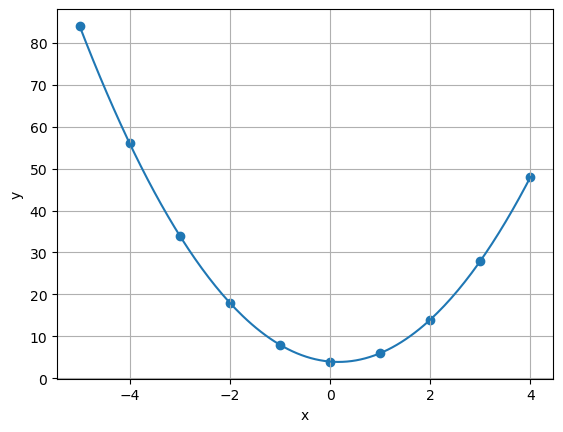

In [3]:
x_data = np.array([-5,-4,-3,-2,-1,0,1,2,3,4])
y_data = np.array([84,56,34,18,8,4,6,14,28,48])

a, b, c = fit_parabola_normal_equation(x_data, y_data)

print(f"y = {a:.4f}x^2 + {b:.4f}x + {c:.4f}")

x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_smooth = a*x_smooth**2 + b*x_smooth + c

plt.scatter(x_data, y_data)
plt.plot(x_smooth, y_smooth)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

y = 3.0152x^2 + -0.5788x + 6.9818


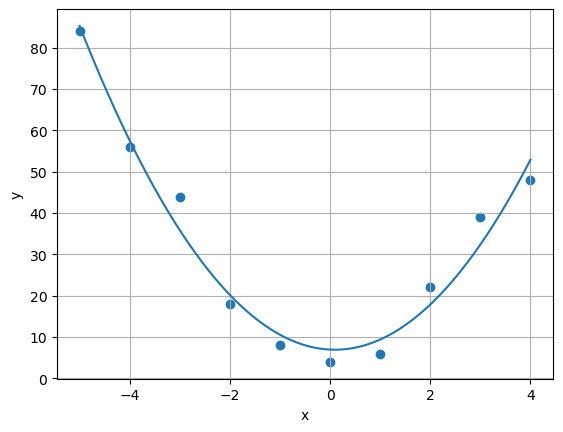

In [5]:
k = 9

x_data = np.array([-5,-4,-3,-2,-1,0,1,2,3,4])

y_data = np.array([
    84, 56, 34+(k+1), 18, 8,
    4, 6, 14+(k-1), 28+(k+2), 48
])

a, b, c = fit_parabola_normal_equation(x_data, y_data)

print(f"y = {a:.4f}x^2 + {b:.4f}x + {c:.4f}")

x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_smooth = a*x_smooth**2 + b*x_smooth + c

plt.scatter(x_data, y_data)
plt.plot(x_smooth, y_smooth)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()